# Exercise 3.3 (Implementation of the Finite Difference Method for the 1D Poisson equation)
In this exercise, we solve the one-dimensional boundary value problem

$$
\begin{cases}
-u''(x)=f(x), & x\in(0,1),\\
u(0)=0,\quad u(1)=0.
\end{cases}
$$


### Import packages

We use `numpy` for numerical computations and `matplotlib` for plotting.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Finite difference system

### Grid points
We discretize the interval $(0,1)$ using the interior grid points

$$
x_i = ih, \qquad h = \frac{1}{N+1}, \qquad i=1,\dots,N.
$$

<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Complete the function 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">grid_points</code>
so that it returns a NumPy array of shape
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">(N,)</code>
containing the grid points.
</p>

</div>

In [3]:
def grid_points(N):
    """Return the N interior grid points for the interval (0, 1)."""
    
    return np.linspace(0, 1, N + 1, endpoint=False)[1:]
    
    pass

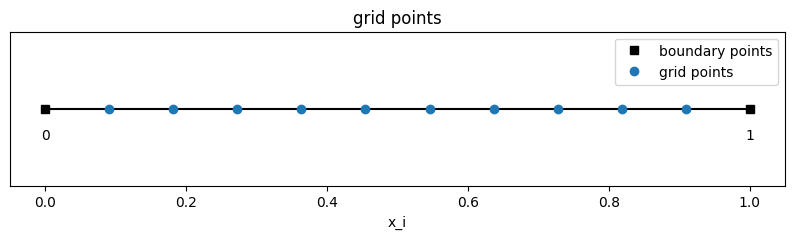

In [4]:
# Let this cell run to check your grid point implementation
N = 10
x_h = grid_points(N)
assert x_h.shape == (N,), "Grid must be of shape (N,)."

plt.figure(figsize=(10, 2))

# axis
plt.hlines(0, 0, 1, color="black")

# boundary points
plt.plot(0, 0, "ks", label="boundary points")
plt.plot(1, 0, "ks")

# grid points
plt.plot(x_h, np.zeros_like(x_h), "o", label="grid points")
plt.text(0, -0.08, "0", ha="center")
plt.text(1, -0.08, "1", ha="center")

plt.xlabel("x_i")
plt.yticks([])
plt.title("grid points")
plt.legend()
plt.ylim(-0.2, 0.2)
plt.grid(False)
plt.show()

*Check: The plot should show uniformly spaced points on the interval $[0,1]$. There should be no grid points on the boundary itself.*

### Stiffness matrix

The second derivative is approximated by

$$
-u''(x_i) \approx -\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}, \quad i=1,\dots,N
$$

Therefore, the matrix has the tridiagonal form

$$
\boldsymbol{A} = \frac{1}{h^2}
\begin{pmatrix}
2 & -1 \\
-1 & 2 & -1 \\
& \ddots & \ddots & \ddots \\
&& -1 & 2 & -1 \\
&&& -1 & 2
\end{pmatrix}.
$$

<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Complete the function 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">build_matrix</code>
so that it returns the matrix A as an array of shape
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">(N,N)</code>.
</p>

</div>

In [5]:
def build_matrix(N):
    """Return the finite-difference matrix for -u'' on (0, 1) with zero Dirichlet data."""
    h = 1 / (N + 1)
    return (2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)) / (h**2)
    pass

In [6]:
# Test build_matrix
N = 10
A = build_matrix(N)

print(A)
assert A.shape == (N,N), "A has to be of shape (N,N)"

[[ 242. -121.    0.    0.    0.    0.    0.    0.    0.    0.]
 [-121.  242. -121.    0.    0.    0.    0.    0.    0.    0.]
 [   0. -121.  242. -121.    0.    0.    0.    0.    0.    0.]
 [   0.    0. -121.  242. -121.    0.    0.    0.    0.    0.]
 [   0.    0.    0. -121.  242. -121.    0.    0.    0.    0.]
 [   0.    0.    0.    0. -121.  242. -121.    0.    0.    0.]
 [   0.    0.    0.    0.    0. -121.  242. -121.    0.    0.]
 [   0.    0.    0.    0.    0.    0. -121.  242. -121.    0.]
 [   0.    0.    0.    0.    0.    0.    0. -121.  242. -121.]
 [   0.    0.    0.    0.    0.    0.    0.    0. -121.  242.]]


*There should be a printed matrix with values equal to 242 on the diagonal, and -121 on the side diagonals.*

### Solve the linear system

We solve

$$
A\boldsymbol{u}_h=\boldsymbol{b},
\qquad \text{where} \qquad
b_i = f(x_i), \qquad i=1,\dots,N.
$$

The vector $\boldsymbol{u}_h=(u_{h,1},\dots,u_{h,N})^\top$ contains the finite-difference approximations to the exact solution at the interior grid points: $u_{h,i} \approx u(x_i)$.


<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Complete the function 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">solve_pde</code>
which computes the finite difference solution for the Poisson equation. It is given the right hand side 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">f</code>
as a Python function and the number of grid points
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">N</code>.
It should return an array of shape
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">(N,)</code>
containing the values of the finite-difference approximation at the grid points.
</p>
<p>
Use <code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">numpy.linalg.solve</code>.
</p>

</div>

In [7]:
def solve_pde(f, N):
    """Solve -u'' = f on (0, 1) with u(0)=u(1)=0 using N interior grid points."""
    x_h = grid_points(N)
    A = build_matrix(N)
    b = f(x_h)
    u_h = np.linalg.solve(A, b)
    return u_h
    pass


## Application of the solver

We consider the right hand side 
$$f(x) = \pi^2 \sin(\pi x), \qquad x\in(0,1).$$

Note that the exact solution is given by 
$$
u(x) = \sin(\pi x), \qquad x\in(0,1).$$

In [8]:
def f(x):
    """Right-hand side of the PDE."""
    return np.pi**2 * np.sin(np.pi * x)


def u(x):
    """Exact solution."""
    return np.sin(np.pi * x)


In [9]:
# basic usage of the solver
N = 10
u_h = solve_pde(f, N) 

assert u_h.shape == (N,), "u_h must have shape (N,)"

<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Plot the numerical solution 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">u_h</code>
for <code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">N=10</code>
together with the exact solution. Use a finer grid for the representation of the exact solution.
</p>

</div>

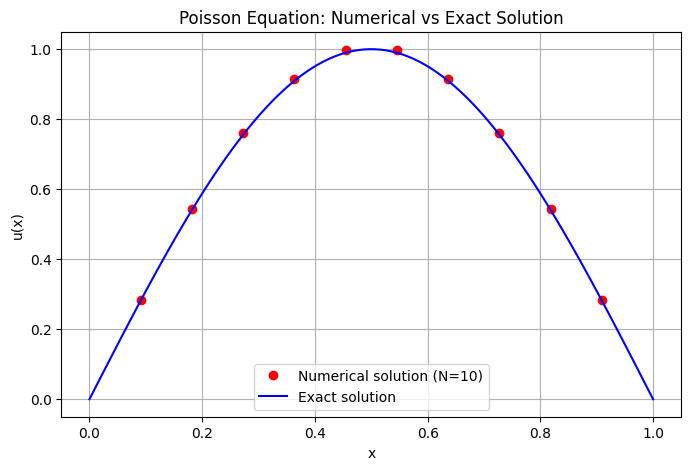

In [10]:
x_h = grid_points(N)
u_h = solve_pde(f, N)

x_fine = np.linspace(0, 1, 100)
u_exact = u(x_fine)

plt.figure(figsize=(8, 5))

plt.plot(x_h, u_h, 'ro', label=f'Numerical solution (N={N})')

plt.plot(x_fine, u_exact, 'b-', label='Exact solution')

plt.title("Poisson Equation: Numerical vs Exact Solution")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.show()

## Error analysis
Consider the maximum error
$$
\|u_h-u\|_\infty
=
\max_i |u_i-u(x_i)|.
$$

<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Compute the maximum error
for 
<code style="background-color: var(--code-bg); color: var(--code-color); padding: 0.1em 0.3em; border-radius: 4px;">N=10</code>.
</p>

</div>


In [11]:
N = 10

x_h = grid_points(N)

u_h = solve_pde(f, N)

u_true = u(x_h)

max_error = np.max(np.abs(u_h - u_true))
print(f"Maximum error for N={N}: {max_error:.6e}") 


Maximum error for N=10: 6.755590e-03


### Convergence study

We repeat the computation for several values of $N$:

$$
N=10,20,40,80,160,320.
$$

<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Repeat the computation for all the values of N.
</p>

</div>

In [12]:
Ns = np.array([10, 20, 40, 80, 160, 320])
errors = []

for N in Ns:

    x_h = grid_points(N)
    u_h = solve_pde(f, N)
    
    u_true = u(x_h)
    
    max_err = np.max(np.abs(u_h - u_true))

    errors.append(max_err)
    
    print(f"N = {N:3d} | Max Error = {max_err:.2e}")
    pass

N =  10 | Max Error = 6.76e-03
N =  20 | Max Error = 1.86e-03
N =  40 | Max Error = 4.89e-04
N =  80 | Max Error = 1.25e-04
N = 160 | Max Error = 3.17e-05
N = 320 | Max Error = 7.98e-06


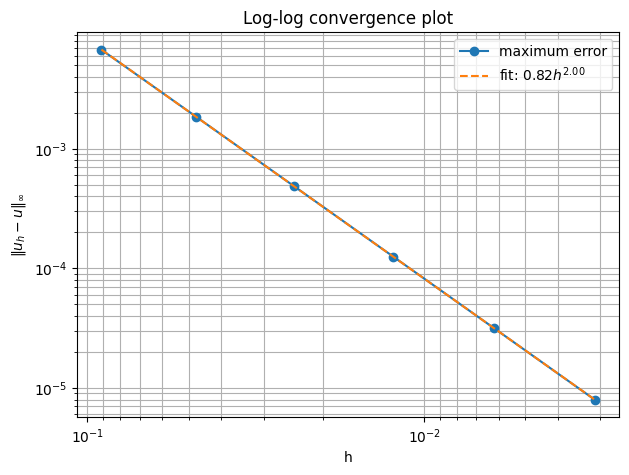

In [13]:
# Let this run for a log-log convergence plot and rate estimation

hs = 1.0 / (Ns + 1) # mesh sizes
errors = np.array(errors)

# Estimate convergence rate by log-log linear regression
coeffs = np.polyfit(np.log(hs), np.log(errors), deg=1)
r = coeffs[0]
C = np.exp(coeffs[1])
fit_errors = C * hs**r

plt.figure(figsize=(7, 5))
plt.loglog(hs, errors, "o-", label="maximum error")
plt.loglog(hs, fit_errors, "--", label=fr"fit: ${C:.2f} h^{{{r:.2f}}}$")

plt.xlabel("h")
plt.ylabel(r"$\|u_h - u\|_\infty$")
plt.title("Log-log convergence plot")
plt.grid(True, which="both")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


<div style="
    background-color: #b8e0ff;
    border-left: 6px solid #003366;
    padding: 1em;
    margin: 1em 0;
    border-radius: 8px;
    color: black;
    --code-bg: #83bbe6;
    --code-color: #003366;
">

<strong>Exercise</strong>
<p>
Did we verify numerically that the method is second-order accurate? Answer in a markdown.
</p>

</div>

*Answer here.*


Yes, the numerical results confirm that the finite difference method is second-order accurate.
The log-log convergence plot shows that the maximum error decreases proportionally to $h^2$,
as indicated by the fitted slope of approximately $r \approx 2.00$.
This means that when the mesh size $h$ is halved (i.e., $N$ is doubled),
the error decreases by a factor of approximately 4, which is consistent with
second-order accuracy $\|u_h - u\|_\infty = \mathcal{O}(h^2)$.